Starting SVR Time-Series Cross-Validation...
Fold 1 → R²=-0.1382, NMSE=0.0775, NMAE=0.1757
Fold 2 → R²=-0.2784, NMSE=0.0658, NMAE=0.1289
Fold 3 → R²=0.1625, NMSE=0.0488, NMAE=0.1873
Fold 4 → R²=-0.1132, NMSE=0.0760, NMAE=0.1562
Fold 5 → R²=0.2075, NMSE=0.0432, NMAE=0.1764

========= SVR TIME-SERIES CV RESULTS =========
NMAE : 0.1649 ± 0.0206
NMSE : 0.0623 ± 0.0140
R²   : -0.0320 ± 0.1864
MAPE : 128.10% ± 41.27%

========== DIEBOLD-MARIANO TEST ==========
SVR vs Naive (Lag-12)
DM Stat : 5.1730
p-value : 0.0000


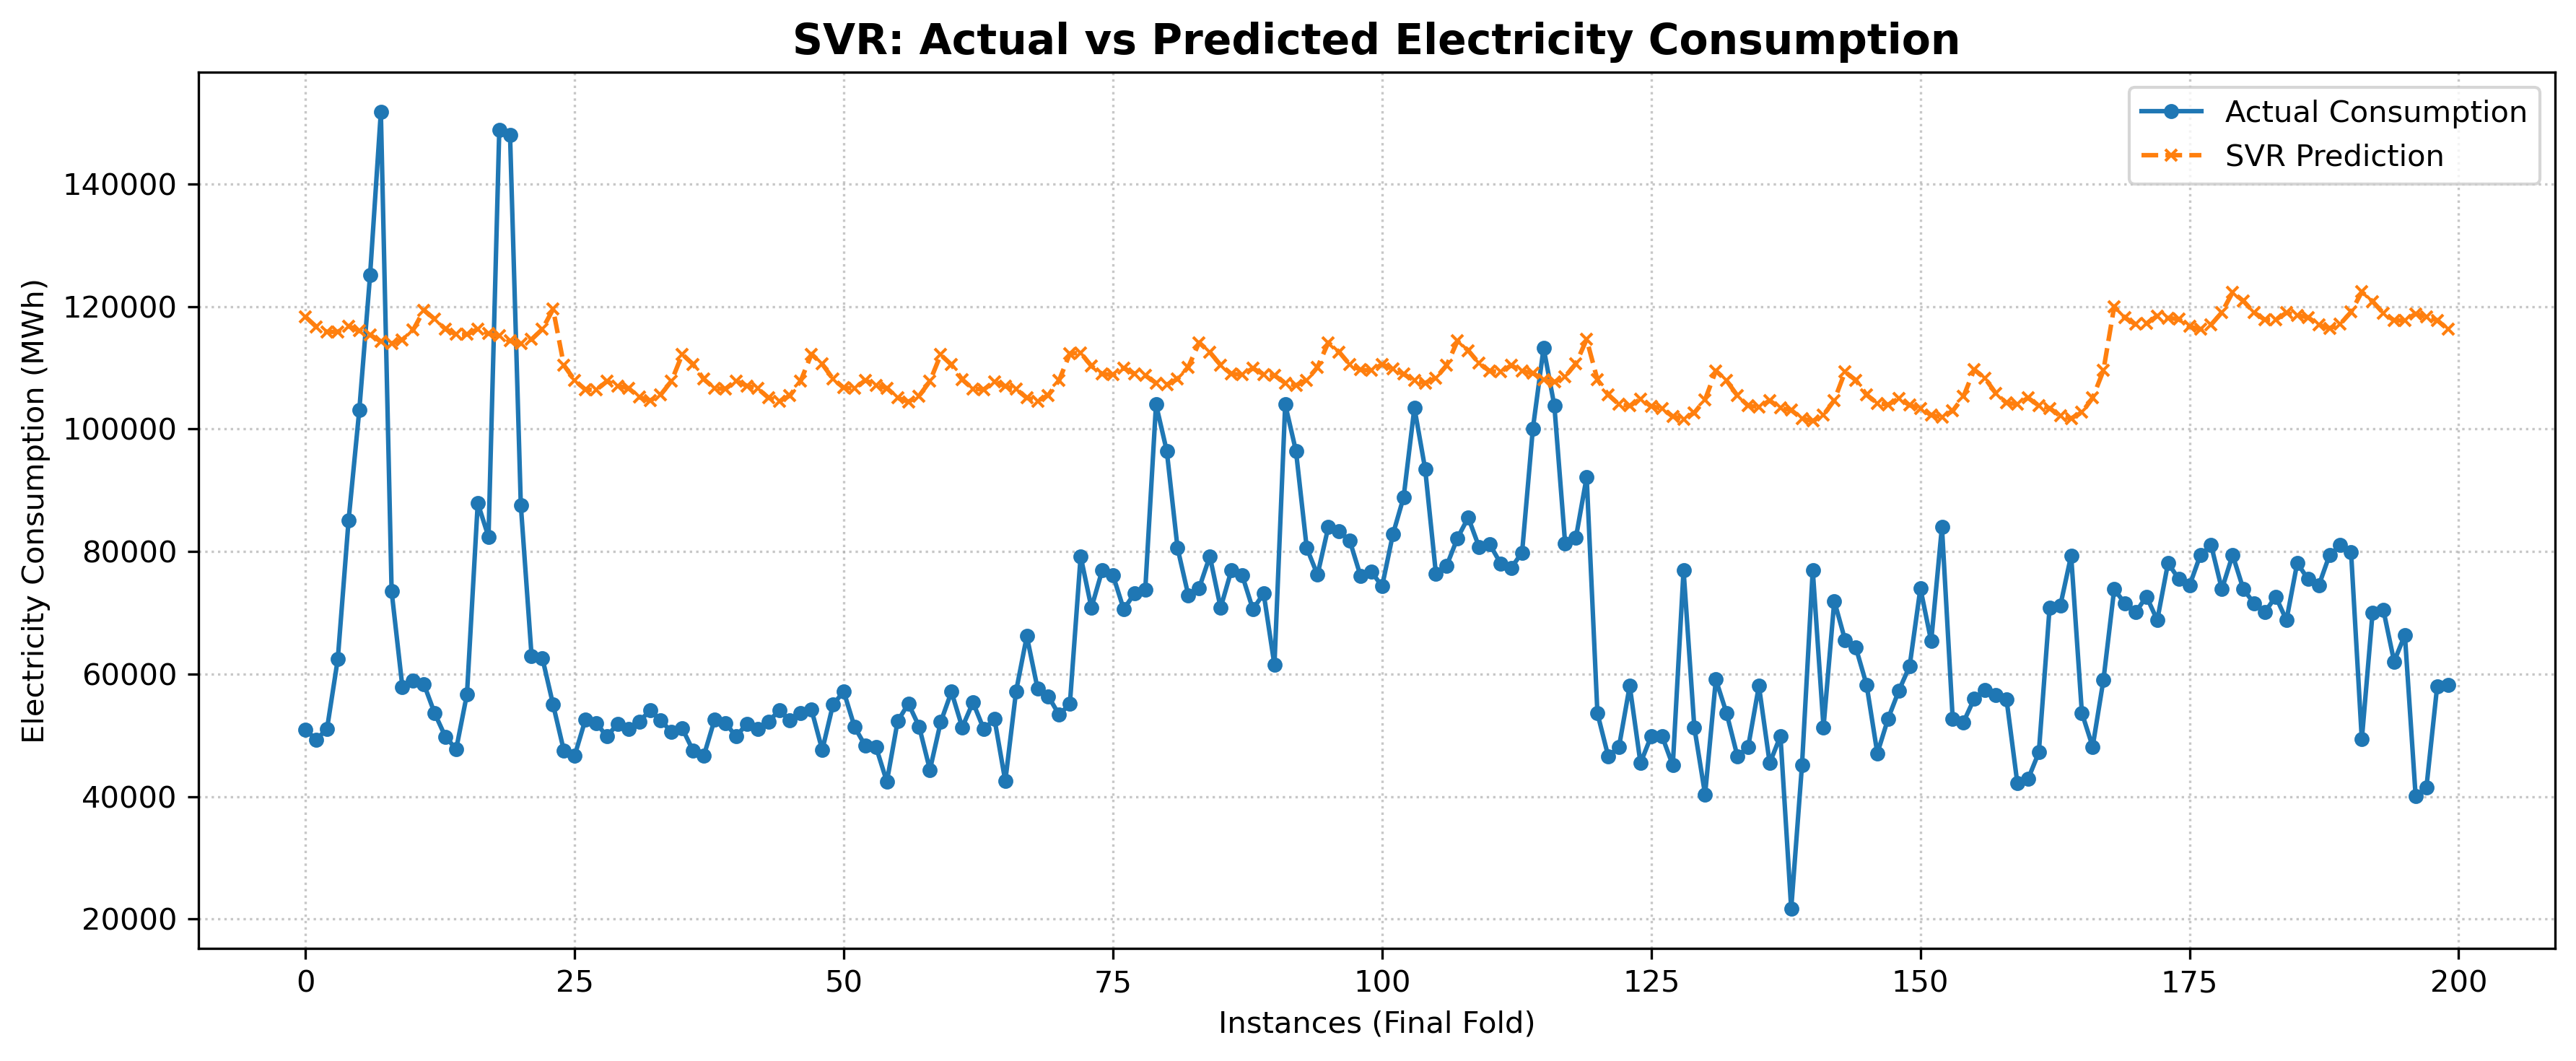

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ---------------------------------------------------------
# 1) DIEBOLD-MARIANO TEST FUNCTION
# ---------------------------------------------------------
def diebold_mariano(y_true, y_pred1, y_pred2):
    e1 = y_true - y_pred1
    e2 = y_true - y_pred2

    d = e1**2 - e2**2

    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)

    dm_stat = mean_d / np.sqrt(var_d / len(d))
    p_value = 2 * (1 - stats.norm.cdf(np.abs(dm_stat)))

    return dm_stat, p_value


def main():

    # ---------------------------------------------------------
    # 2) DATA LOAD
    # ---------------------------------------------------------
    OUTPUT_PATH = os.path.join(
        "..", "..", "processed_data", "final", "ML_En.xlsx"
    )

    df = pd.read_excel(OUTPUT_PATH)

    df["Plate"] = df["Plate"].astype(str).str.lower()
    df = df.sort_values(["Plate", "Year", "Month"]).reset_index(drop=True)

    # ---------------------------------------------------------
    # 3) LAG FEATURES
    # ---------------------------------------------------------
    lag = 12

    for l in range(1, lag + 1):
        df[f"lag_{l}"] = df.groupby("Plate")["Consumption"].shift(l)

    df = df.dropna().reset_index(drop=True)

    # ---------------------------------------------------------
    # 4) FEATURES
    # ---------------------------------------------------------
    features = [
        "Lighting", "Public", "Residential", "Industry", "Agriculture",
        "Population", "Month", "Season", "Region",
        "Latitude", "Longitude", "Daylight Duration", "Altitude"
    ] + [f"lag_{i}" for i in range(1, lag + 1)]

    X = df[features].copy()
    y = df["Consumption"].values

    # ---------------------------------------------------------
    # 5) TIME SERIES CV
    # ---------------------------------------------------------
    tscv = TimeSeriesSplit(n_splits=5)

    fold_metrics = []

    print("Starting SVR Time-Series Cross-Validation...")

    final_y_true = None
    final_y_pred = None

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), 1):

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # -----------------------------
        # SCALING (CRITICAL FOR SVR)
        # -----------------------------
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test = scaler.transform(X_test)

        # -----------------------------
        # SVR MODEL
        # -----------------------------
        model = SVR(
            kernel="rbf",
            C=100,
            gamma="scale",
            epsilon=0.1
        )

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        # -----------------------------
        # METRICS
        # -----------------------------
        y_range = y_test.max() - y_test.min()
        y_range_safe = y_range if y_range != 0 else 1

        mse_val = mean_squared_error(y_test, y_pred)
        mae_val = mean_absolute_error(y_test, y_pred)

        nmse = mse_val / (y_range_safe ** 2)
        nmae = mae_val / y_range_safe
        r2 = r2_score(y_test, y_pred)

        mape = np.mean(
            np.abs((y_test - y_pred) /
                   (np.abs(y_test) + 1e-10))
        ) * 100

        fold_metrics.append([r2, nmse, nmae, mape])

        print(
            f"Fold {fold} → "
            f"R²={r2:.4f}, NMSE={nmse:.4f}, NMAE={nmae:.4f}"
        )

        if fold == tscv.n_splits:
            final_y_true = y_test
            final_y_pred = y_pred

    # ---------------------------------------------------------
    # 6) RESULTS
    # ---------------------------------------------------------
    fold_metrics = np.array(fold_metrics)

    print("\n" + "=" * 50)
    print("========= SVR TIME-SERIES CV RESULTS =========")
    print("=" * 50)

    print(
        f"NMAE : {fold_metrics[:,2].mean():.4f} ± {fold_metrics[:,2].std():.4f}"
    )
    print(
        f"NMSE : {fold_metrics[:,1].mean():.4f} ± {fold_metrics[:,1].std():.4f}"
    )
    print(
        f"R²   : {fold_metrics[:,0].mean():.4f} ± {fold_metrics[:,0].std():.4f}"
    )
    print(
        f"MAPE : {fold_metrics[:,3].mean():.2f}% ± {fold_metrics[:,3].std():.2f}%"
    )

    print("=" * 50)

    # ---------------------------------------------------------
    # 7) DIEBOLD-MARIANO TEST
    # ---------------------------------------------------------
    y_naive = pd.Series(final_y_true).shift(12).bfill().values

    dm_stat, p_value = diebold_mariano(
        final_y_true,
        final_y_pred,
        y_naive
    )

    print("\n" + "=" * 50)
    print("========== DIEBOLD-MARIANO TEST ==========")
    print("=" * 50)

    print("SVR vs Naive (Lag-12)")
    print(f"DM Stat : {dm_stat:.4f}")
    print(f"p-value : {p_value:.4f}")

    print("=" * 50)

    # ---------------------------------------------------------
    # 8) PLOT
    # ---------------------------------------------------------
    plt.figure(figsize=(12, 5), dpi=300)

    plot_limit = min(200, len(final_y_true))

    plt.plot(
        final_y_true[:plot_limit],
        label="Actual Consumption",
        marker="o",
        markersize=4,
        linewidth=1.5
    )

    plt.plot(
        final_y_pred[:plot_limit],
        label="SVR Prediction",
        linestyle="--",
        marker="x",
        markersize=4,
        linewidth=1.5
    )

    plt.title(
        "SVR: Actual vs Predicted Electricity Consumption",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel("Instances (Final Fold)")
    plt.ylabel("Electricity Consumption (MWh)")

    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.7)

    plt.tight_layout()
    plt.savefig("svr_results.png")
    plt.show()


if __name__ == "__main__":
    main()